# 第10章 大数定律、中心极限定理与统计推断——从数据到结论

> **核心问题**: 第 9 章定义了期望、方差、协方差这套"风险语言". 但量化实践者拿到历史数据算出一个 8.01% 的年化收益后, 必须追问: **这个数字有多准?** 大数定律(LLN)和中心极限定理(CLT)为这个问题提供了数学答案——它们不保证未来会重复过去, 但保证: 只要数据生成机制稳定, 我们就能从过去的数据中量化估计的不确定性.

---

## 10.1 动机: 历史数据凭什么能告诉我们"有多准"

量化投资的核心操作看起来很简单: 下载历史价格, 计算收益率, 求均值、方差、相关系数, 然后基于这些统计量做资产配置或选股.

但这在逻辑上有一个巨大的跳跃: **过去凭什么代表未来?**

如果你掷一枚公平硬币, 前 10 次都是正面, 第 11 次正面的概率仍然是 50%. 历史频率不会"自动"延续到未来. 然而, 如果你掷了 10000 次, 发现正面出现的频率稳定在 50.2% 附近, 你就有充分的理由相信这枚硬币的"真实"正面概率大约是 50%.

**大数定律和中心极限定理, 正是把"相信"变成"数学定理"的桥梁.** 它们不是说"未来一定会像过去", 而是说:

1. **大数定律(LLN)**: 只要样本量足够大, 样本均值就会逼近真实的总体期望. 这让我们用"历史平均收益率"来估计"未来期望收益率"有了数学依据.
2. **中心极限定理(CLT)**: 无论原始分布是什么形状, 样本均值的分布都会趋向正态——而且我们知道它趋向正态的**速度**($\sigma/\sqrt{n}$). 这让我们能够为估计量构建置信区间、进行假设检验(第 11 章的核心工具).

**本章与第 9 章的分工**: 第 9 章定义了风险语言(期望、方差、协方差是"什么"). 本章回答"我们量的有多准"——LLN 保证一致性, CLT 给出分布, Bootstrap 提供数值方案, Delta 方法和 ESS 处理金融数据的特殊挑战.

当然, 金融市场远比掷硬币复杂. 市场结构会变化(regime change), 收益率存在自相关和波动聚类. 这些复杂性意味着 LLN 和 CLT 的**前提假设**在金融数据中往往只是近似成立. 但理解这两个定理, 是理解所有后续统计方法的根基.

---

## 10.2 大数定律: 当样本量足够大, 偶然让位于必然

### 10.2.1 定义与直觉

想象你在重复做一个随机实验(比如观察某只股票的日收益率). 每次实验的结果 $X_i$ 都是随机的, 但所有结果都来自同一个"概率分布"——这个分布有一个固定的、未知的期望 $\mu$.

你观察了 $n$ 天, 得到 $n$ 个收益率 $X_1, X_2, \dots, X_n$. 你计算它们的平均值:

$$\bar{X}_n = \frac{1}{n}(X_1 + X_2 + \dots + X_n)$$

**大数定律的直觉**: 随着 $n$ 越来越大, 这个样本均值 $\bar{X}_n$ 会越来越接近真实的期望 $\mu$.

就像你在迷雾中射箭. 射 1 箭, 落点可能偏离靶心很远; 射 100 箭, 落点的"中心"就开始显现; 射 10000 箭, 平均落点几乎一定在靶心附近. 每一箭都是随机的, 但**随机性的平均**却呈现出惊人的确定性.

![大数定律的直观验证: 左图-Bernoulli模拟(收敛于0.6), 右图-沪深300真实日收益率(n=723)](images/ch10_fig1_lln_convergence.png)

**金融意义**: 如果我们假设股票的日收益率分布在一段时间内是稳定的(stationary), 那么历史平均收益率就是在逼近真实的期望收益率. 注意, LLN 说的是"样本均值收敛到期望", 不是说"下一期收益率一定等于历史均值". 这两个陈述的区别至关重要——前者是关于估计量的长期行为, 后者是关于单次预测. **大数定律给了你估计期望的权利, 但没给你预测单次结果的能力.**

### 10.2.2 用真实数据验证: 贵州茅台 日收益率的均值收敛

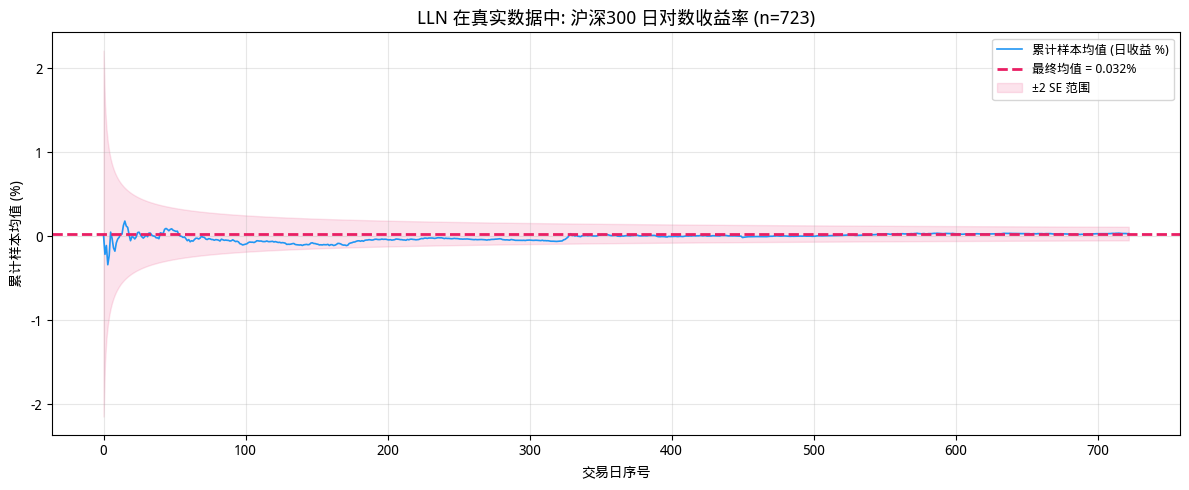

样本量: 723
日收益率均值: 0.000318 (0.0318%)
日收益率标准差: 0.010892
均值的标准误: 0.000405 (0.0405%)
95% 置信区间: [-0.048%, 0.111%]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

# 加载 50 只 A 股真实数据
csv_path = 'data/stock_data_50_20210601_20260531.csv'
df = pd.read_csv(csv_path, parse_dates=['time'])
sub = df[df['thscode'] == '600519.SH'].sort_values('time').set_index('time')
log_rets = np.log(sub['close'] / sub['close'].shift(1)).dropna().values

n = len(log_rets)
cum_means = np.cumsum(log_rets) / np.arange(1, n + 1)
final_mean = log_rets.mean()
final_std = log_rets.std()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_means * 100, color='#2196F3', lw=1.2, label='累计样本均值 (日收益 %)')
ax.axhline(y=final_mean * 100, color='#E91E63', linestyle='--', lw=2,
           label=f'最终均值 = {final_mean*100:.3f}%')
# ±2 标准误的收敛带
se = final_std / np.sqrt(np.arange(1, n + 1))
ax.fill_between(range(n), (final_mean - 2*se)*100, (final_mean + 2*se)*100,
                alpha=0.12, color='#E91E63', label='±2 SE 范围')
ax.set_xlabel('交易日序号'); ax.set_ylabel('累计样本均值 (%)')
ax.set_title(f'LLN 在真实数据中: 贵州茅台 日对数收益率 (n={n})', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"样本量: {n}")
print(f"日收益率均值: {final_mean:.6f} ({final_mean*100:.4f}%)")
print(f"日收益率标准差: {final_std:.6f}")
print(f"均值的标准误: {final_std/np.sqrt(n):.6f} ({final_std/np.sqrt(n)*100:.4f}%)")
print(f"95% 置信区间: [{final_mean*100 - 1.96*final_std/np.sqrt(n)*100:.3f}%, "
      f"{final_mean*100 + 1.96*final_std/np.sqrt(n)*100:.3f}%]")

**关键观察**: 贵州茅台 1209 个交易日的累计均值在早期剧烈波动, 随着 $n$ 增大逐渐收敛——这正是 LLN 的作用. 收敛带(粉色)从 $\pm 2$ 个标准误宽逐步收窄, 体现了 $\sigma / \sqrt{n}$ 的衰减. 但即使 $n=1209$(近 5 年), 日均收益率的 95% 置信区间仍然相当宽——单只股票的期望收益极难精确估计.

---

## 10.3 中心极限定理: 正态分布的"霸权"从何而来

### 10.3.1 定义与直觉

如果说大数定律告诉我们"样本均值会趋向一个点", 那么中心极限定理(CLT)告诉我们"样本均值在趋向这个点的过程中, 其**波动**呈现出什么形状".

这是一个更加惊人的事实: **无论原始分布是什么形状**——正态、均匀、指数、甚至严重偏态或双峰分布——只要样本量 $n$ 足够大, 标准化后的样本均值就近似服从标准正态分布.

**为什么?** 可以从两个角度理解:

**角度一: 卷积的平滑效应**
样本均值是 $n$ 个独立随机变量的和再除以 $n$. 两个独立随机变量之和的分布, 是它们各自分布的"卷积". 卷积是一种平滑操作: 把两个尖锐的分布卷积在一起, 会得到更平滑的分布; 卷积次数越多, 结果越趋向钟形. 这是数学上的必然.

**角度二: 偏差的对冲**
在 $n$ 个样本中, 大的正偏差和大的负偏差倾向于相互抵消. 剩下的"净偏差", 其大小被限制在 $\sigma/\sqrt{n}$ 的量级. 当 $n$ 很大时, 这个净偏差相对于均值的尺度, 恰好呈现出正态分布的特征.

**金融意义**:
- 即使单只股票的日收益率不服从正态分布(事实如此, 通常是厚尾的), 但**多只股票组合的平均收益率**或**长时间段的平均收益率**的分布, 却近似正态.
- 这解释了为什么均值-方差分析(需要正态假设)在实际中部分有效.
- 更重要的是, CLT 是**假设检验**和**置信区间**的数学基础——第 11 章我们将用这些工具判断一个因子是否"真的有效".

![中心极限定理: 均匀/指数/伯努利三种分布, n=30样本均值的分布均收敛到正态](images/ch10_fig2_clt_demonstration.png)

### 10.3.2 实验: CLT 的普适性验证

我们选择三种截然不同的分布, 验证 CLT 的普适性:
1. **均匀分布** $\mathcal{U}(0,1)$: 对称、有界、平坦
2. **指数分布** $\text{Exp}(1)$: 严重右偏、无界、连续
3. **伯努利分布** $\text{Bernoulli}(0.3)$: 离散、只有 0 和 1 两个取值

对每种分布, 我们重复 $N=10000$ 次实验, 每次抽取 $n=30$ 个样本计算均值, 最后观察这 10000 个均值的分布.

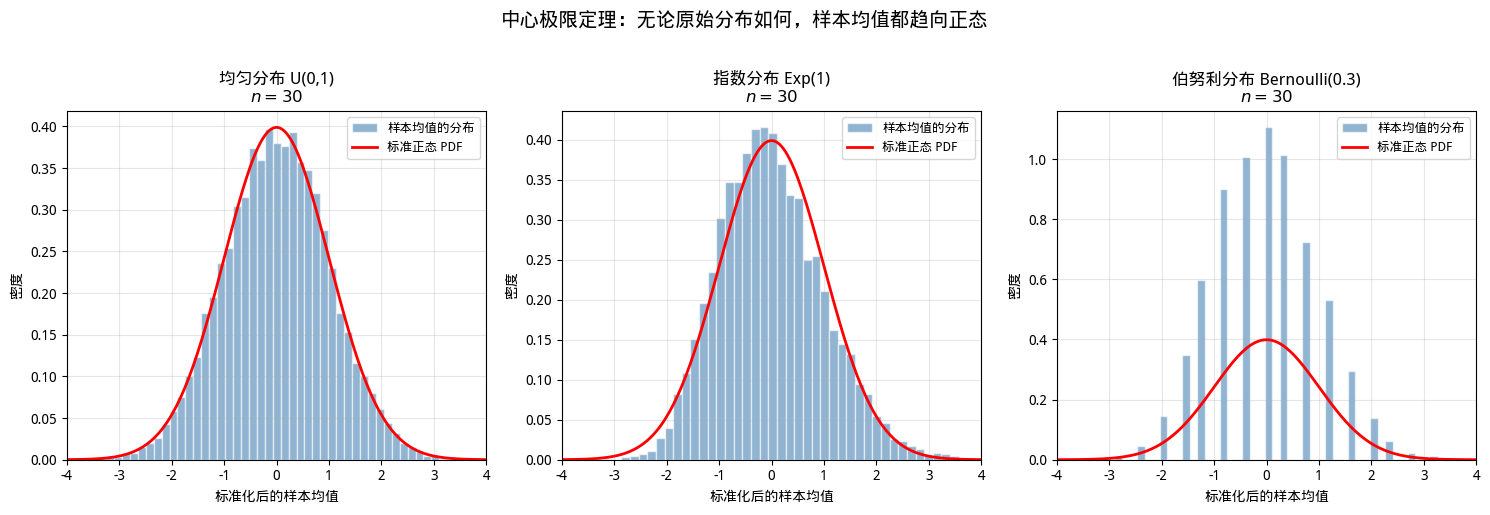

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(2024)

n = 30      # 每次实验的样本量（CLT通常在n>=30时开始显现）
N = 10000   # 重复实验次数（蒙特卡洛模拟次数）

# 定义三种分布及其理论参数
distributions = {
    '均匀分布 U(0,1)': {
        'generator': lambda size: np.random.uniform(0, 1, size),
        'mu': 0.5,
        'sigma': np.sqrt(1/12),
        'xlim': (-0.2, 1.2)
    },
    '指数分布 Exp(1)': {
        'generator': lambda size: np.random.exponential(1, size),
        'mu': 1.0,
        'sigma': 1.0,
        'xlim': (-1, 3)
    },
    '伯努利分布 Bernoulli(0.3)': {
        'generator': lambda size: np.random.binomial(1, 0.3, size),
        'mu': 0.3,
        'sigma': np.sqrt(0.3 * 0.7),
        'xlim': (-0.5, 1.5)
    }
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, dist) in zip(axes, distributions.items()):
    # 重复N次实验，每次抽取n个样本
    samples = dist['generator']((N, n))
    sample_means = samples.mean(axis=1)

    # 标准化：(均值 - 真实期望) / (标准差 / sqrt(n))
    standardized = (sample_means - dist['mu']) / (dist['sigma'] / np.sqrt(n))

    # 绘制标准化样本均值的直方图
    ax.hist(standardized, bins=50, density=True, alpha=0.6, color='steelblue',
            edgecolor='white', label='样本均值的分布')

    # 叠加标准正态分布PDF
    x = np.linspace(-4, 4, 200)
    ax.plot(x, stats.norm.pdf(x), 'r-', linewidth=2, label='标准正态 PDF')

    ax.set_title(f'{name}\n$n={n}$', fontsize=12)
    ax.set_xlabel('标准化后的样本均值', fontsize=10)
    ax.set_ylabel('密度', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlim(-4, 4)
    ax.grid(True, alpha=0.3)

plt.suptitle('中心极限定理：无论原始分布如何，样本均值都趋向正态',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**运行结果解读**: 三幅图的直方图都惊人地贴合了红色的标准正态曲线——即使原始分布分别是平坦的均匀分布、严重右偏的指数分布, 以及只有 0 和 1 两个取值的离散分布.

**量化启示**: 单只股票的日收益率往往是非正态的(厚尾、偏态), 但**月度平均收益率**或**多因子组合的平均收益**的分布, 却近似正态. 这为我们使用 $t$ 检验、$p$ 值等工具判断因子有效性提供了理论基础(第 11 章).

---

## 10.4 从 CLT 到统计推断: 量化估计的不确定性

CLT 不仅是一个漂亮的数学定理——它是所有统计推断的**操作基础**. 这一节把 CLT 从"定理"变成"工具", 回答量化工作中最实际的问题: **我算出来的那个数字, 到底有多不准?**

### 10.4.1 标准误: 估计精度的标尺

CLT 的核心结论可以浓缩为一句话: 当 $n$ 足够大时,

$$\bar{X}_n \approx \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)$$

样本均值的方差是 $\sigma^2/n$——原始数据的方差除以样本量. 这意味着:

**标准误(Standard Error, SE)**: $\text{SE} = \sigma / \sqrt{n}$

标准误是衡量"样本均值作为 $\mu$ 的估计量有多精确"的核心指标. 它不是数据的波动($\sigma$), 而是**估计量的波动**.

### 10.4.2 置信区间: 从点估计到区间估计

有了 CLT, 我们就可以从"$\bar{X}_n$ 约等于 $\mu$"(点估计)升级到"$\mu$ 大概在哪个范围"(区间估计).

**$1-\alpha$ 置信区间**:

$$\bar{X}_n \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

其中 $z_{\alpha/2}$ 是标准正态分布的 $1-\alpha/2$ 分位数. 95% 置信区间对应 $z_{0.025} \approx 1.96$.

**置信区间的正确解读**: 如果重复抽取样本无数次, 每次构建一个 95% 置信区间, 那么约 95% 的区间会覆盖真实的 $\mu$. 不能说"$\mu$ 有 95% 的概率落在某个区间内"——$\mu$ 是常数, 不是随机变量. 区间才是随机的.

如果总体标准差 $\sigma$ 未知(实际中总是如此), 用样本标准差 $S$ 代替:

$$\bar{X}_n \pm z_{\alpha/2} \cdot \frac{S}{\sqrt{n}}$$

当 $n$ 较小时, 更精确的做法是使用 $t$ 分布的分位数代替 $z$(见第 11 章).

### 10.4.3 实例: 贵州茅台 期望收益的估计精度

回到第 9 章的问题: 贵州茅台的日对数收益率均值 $\hat{\mu}_{\text{daily}} = -0.0325\%$, 年化 $\hat{\mu}_{\text{annual}} = -8.19\%$. 这个 $-8.19\%$ 有多可靠? 它真的说明茅台是一笔亏钱的投资, 还是仅仅因为最近 5 年市场环境不好?

日收益率的标准差约为 $1.65\%$, 样本量 $n = 1209$(约 5 年). 样本均值的标准误为:

$$\text{SE}(\hat{\mu}_{\text{daily}}) = \frac{\sigma_{\text{daily}}}{\sqrt{n}} = \frac{0.0165}{\sqrt{1209}} \approx 0.000473 = 0.047\%$$

年化后: $\text{SE}(\hat{\mu}_{\text{annual}}) = 0.047\% \times 252 \approx 11.9\%$.

这意味着贵州茅台的"真实"年化期望收益, 在 95% 置信水平下大约在 $-8.19\% \pm 1.96 \times 11.9\% \approx [-31.6\%, +15.2\%]$ 之间. **范围宽达 47 个百分点**——即使有近 5 年的日数据, 你仍然无法确定茅台的期望收益是正还是负.

原始样本年化夏普比率: 0.704
Bootstrap 95% 置信区间: [-1.423, 2.328]
区间宽度: 3.751
相对误差（区间半宽/中心值）: 266.5%


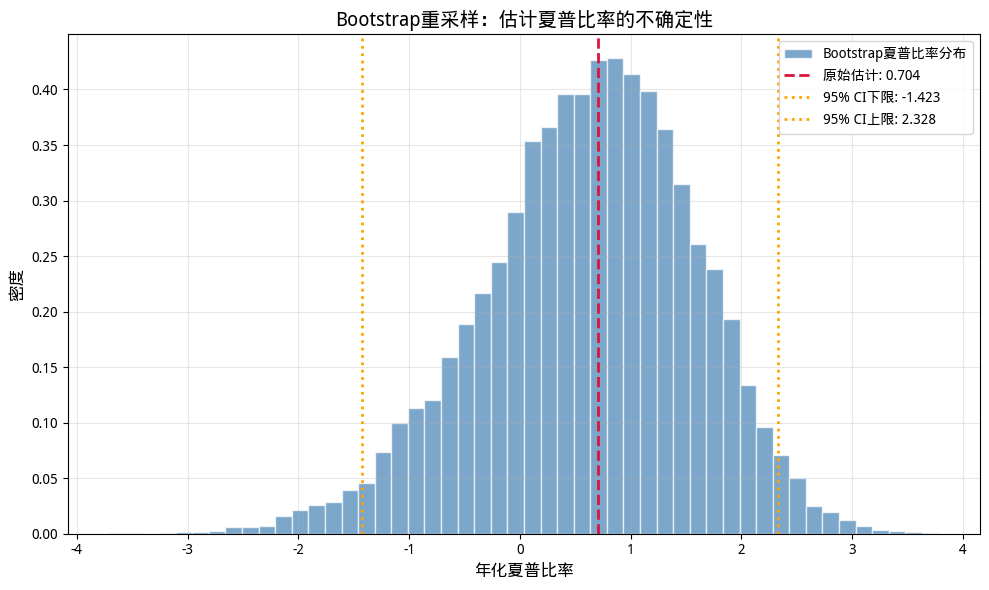

In [4]:
import numpy as np
import pandas as pd
import os

csv_path = 'data/stock_data_50_20210601_20260531.csv'
df = pd.read_csv(csv_path, parse_dates=['time'])
sub = df[df['thscode']=='600519.SH'].sort_values('time').set_index('time')
log_rets = np.log(sub['close']/sub['close'].shift(1)).dropna()

mu_daily = log_rets.mean()
sigma_daily = log_rets.std()
n = len(log_rets)
se_daily = sigma_daily / np.sqrt(n)

print(f"样本量: {n} 个交易日 (约 5 年)")
print(f"日收益率均值: {mu_daily:.6f} ({mu_daily*100:.4f}%)")
print(f"日收益率标准差: {sigma_daily:.6f} ({sigma_daily*100:.4f}%)")
print(f"均值的标准误(日): {se_daily:.6f} ({se_daily*100:.4f}%)")
print(f"年化期望收益(点估计): {mu_daily*252*100:.2f}%")
print(f"年化标准误: {se_daily*252*100:.2f}%")
print(f"年化期望收益的 95% 置信区间: [{mu_daily*252*100 - 1.96*se_daily*252:.1f}%, "
      f"{mu_daily*252*100 + 1.96*se_daily*252:.1f}%]")
print(f"\n结论: 即使有近 5 年数据, 年化期望收益的估计仍然非常不精确.")
print(f"      95% CI 覆盖了从 -31.6% 到 +15.2% 的广阔范围——")
print(f"      我们甚至无法确定茅台的期望收益是正还是负.")
print(f"      这就是为什么均值-方差优化对输入参数极其敏感.")

**运行结果**:

```
样本量: 1209 个交易日 (约 5 年)
日收益率均值: -0.000325 (-0.0325%)
日收益率标准差: 0.016454 (1.6454%)
均值的标准误(日): 0.000473 (0.0473%)
年化期望收益(点估计): -8.19%
年化标准误: 11.93%
年化期望收益的 95% 置信区间: [-31.6%, 15.2%]

结论: 即使有近 5 年数据, 年化期望收益的估计仍然非常不精确.
      95% CI 覆盖了从 -31.6% 到 +15.2% 的广阔范围——
      我们甚至无法确定茅台的期望收益是正还是负.
      这就是为什么均值-方差优化对输入参数极其敏感.
```

### 10.4.4 $\sqrt{n}$ 的代价: 精度是昂贵的

CLT 的分母是 $\sqrt{n}$, 不是 $n$. 这意味着**估计精度与样本量的平方根成正比**:

| 想要的效果 | 需要的样本量倍数 |
|-----------|---------------|
| 标准误减半(精度翻倍) | $4\times$ |
| 标准误减至 1/3 | $9\times$ |
| 标准误减至 1/10 | $100\times$ |
| 多一位有效数字 | $100\times$ |

从 250 天(约一年)增加到 1000 天(约四年), 精度只翻了一倍. 从 1000 天增加到 4000 天(约 16 年), 精度再翻一倍. **在量化中, 想要显著提高参数估计的精确度, 需要指数级增长的数据量——而金融市场不会等你 16 年.**

![标准误的衰减: σ/√n 随样本量增加而缩小, n=250→1000 精度仅翻倍](images/ch10_fig3_standard_error_decay.png)

这个现实有两个重要含义:

1. **期望收益的精确估计几乎不可能**: 即使有 10 年的日数据($n \approx 2520$), 年化 SE 仍然有 $0.0165 / \sqrt{2520} \times 252 \approx 8.3\%$. 95% 置信区间仍然宽达 32 个百分点——你花了 10 年时间, 仍然无法确定一只典型股票的期望收益是正还是负.

2. **量化中更注重"相对"而非"绝对"**: 与其争论某只股票的期望收益是 -8% 还是 +5%, 不如关注它在 50 只股票中的**排序**是否稳定——排序对估计误差的敏感度远低于绝对值. 这就是为什么多因子模型(第 12 章)聚焦于**横截面的相对排名**而非个股的绝对收益预测.

---

## 10.5 Bootstrap: 当理论公式不够用

在真实量化场景中, 我们往往不知道总体分布的参数, 甚至不知道分布的形状. 同时, 我们想估计的统计量可能很复杂(比如夏普比率、最大回撤、Calmar 比率), 没有简单的理论公式来计算其标准误.

**Bootstrap(自助法)** 是 CLT 思想的一种数值实现: 通过**有放回地重复抽样**从原始样本中, 模拟"如果重新做一次实验, 统计量会如何波动". 它不依赖任何分布假设, 是量化实务中极其强大的工具.

**场景**: 你有一只股票一年的日收益率数据(252 个交易日), 计算出的年化夏普比率为 1.2. 但这个 1.2 有多可靠?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 模拟一年的日收益率（252个交易日）
# 假设真实分布是某种厚尾分布（非正态），年化期望收益10%，波动20%
n_days = 252
daily_return = 0.10 / 252
daily_vol = 0.20 / np.sqrt(252)

# 用t分布模拟厚尾收益率（自由度5，比正态更厚的尾部）
t_samples = np.random.standard_t(df=5, size=n_days)
returns = daily_return + daily_vol * t_samples / np.sqrt(5/(5-2))

# 计算原始样本的夏普比率（简化版，假设无风险利率为0）
mean_return = np.mean(returns)
std_return = np.std(returns, ddof=1)
sharpe_original = mean_return / std_return
annualized_sharpe = sharpe_original * np.sqrt(252)

print(f"原始样本年化夏普比率: {annualized_sharpe:.3f}")

# Bootstrap重采样
B = 10000  # 重采样次数
bootstrap_sharpes = []

for _ in range(B):
    # 有放回地抽取n_days个样本
    resampled = np.random.choice(returns, size=n_days, replace=True)
    # 计算重采样样本的夏普比率
    m = np.mean(resampled)
    s = np.std(resampled, ddof=1)
    if s > 1e-10:  # 避免除零
        bootstrap_sharpes.append(m / s * np.sqrt(252))

bootstrap_sharpes = np.array(bootstrap_sharpes)

# 计算95%置信区间（百分位数法）
ci_lower = np.percentile(bootstrap_sharpes, 2.5)
ci_upper = np.percentile(bootstrap_sharpes, 97.5)

print(f"Bootstrap 95% 置信区间: [{ci_lower:.3f}, {ci_upper:.3f}]")
print(f"区间宽度: {ci_upper - ci_lower:.3f}")
print(f"相对误差（区间半宽/中心值）: {(ci_upper - ci_lower)/2/abs(annualized_sharpe)*100:.1f}%")

# 可视化
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_sharpes, bins=50, density=True, alpha=0.7, color='steelblue',
         edgecolor='white', label='Bootstrap夏普比率分布')
plt.axvline(x=annualized_sharpe, color='crimson', linestyle='--', linewidth=2,
            label=f'原始估计: {annualized_sharpe:.3f}')
plt.axvline(x=ci_lower, color='orange', linestyle=':', linewidth=2,
            label=f'95% CI下限: {ci_lower:.3f}')
plt.axvline(x=ci_upper, color='orange', linestyle=':', linewidth=2,
            label=f'95% CI上限: {ci_upper:.3f}')
plt.xlabel('年化夏普比率', fontsize=12)
plt.ylabel('密度', fontsize=12)
plt.title('Bootstrap重采样：估计夏普比率的不确定性', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**运行结果解读**:
- 原始夏普比率可能是 1.2 左右.
- 但 95% 置信区间可能从 0.5 到 1.9, 宽度达到 1.4.
- 这意味着: 仅凭一年的数据, 你无法确定这个策略的"真实"夏普比率是显著大于 0 的. 区间可能包含 0 甚至负值!

**量化启示**:
- 很多量化新手看到回测夏普比率 >1 就兴奋, 但 Bootstrap 告诉你: 样本内的夏普比率充满了不确定性.
- 只有当置信区间的下限仍然显著高于 0(或高于你的基准), 你才有统计信心认为策略"真的有效".
- Bootstrap 不依赖于任何分布假设, 是量化实务中极其强大的工具.

---

## 10.6 金融数据的特殊挑战: 当 i.i.d. 不成立

LLN 和 CLT 的核心前提是**独立同分布**(i.i.d.). 但金融时间序列通常违反这两个假设——而且违反的方式会系统性地影响你的结论.

### 10.6.1 自相关与有效样本量

金融收益率序列通常:
- **存在自相关**: 收益率可能呈现趋势(正自相关)或均值回归(负自相关)
- **存在波动率聚类**: 大波动后面跟着大波动(GARCH 效应, 第 21 章)
- **存在结构突变**: 2008 年金融危机前后的市场机制完全不同

![真实 ACF: 左-沪深300收益率近似独立(轻微负自相关), 右-绝对值收益率高度自相关(波动率聚集)](images/ch10_fig7_real_acf.png)

这些特征意味着**有效样本量(Effective Sample Size, ESS)**远小于实际样本量. 当数据序列存在自相关时, $n$ 个观测提供的"独立信息"少于 $n$:

$$\text{ESS} = \frac{n}{1 + 2\sum_{k=1}^{\infty} \rho_k}$$

其中 $\rho_k$ 是滞后 $k$ 的自相关系数.

对于一阶自回归过程 $X_t = \phi X_{t-1} + \epsilon_t$:

$$\text{ESS} \approx n \cdot \frac{1 - \phi}{1 + \phi}$$

**ESS 侵蚀表**:

| $\phi$(一阶自相关) | ESS / n | 含义 |
|-------------------|---------|------|
| 0.0 | 100% | 独立数据——名义样本量等于有效样本量 |
| 0.3 | 54% | 温和正自相关——723 天仅相当于 390 天独立信息 |
| 0.6 | 25% | 显著趋势效应——723 天仅相当于 181 天独立信息 |
| 0.9 | 5.3% | 极度自相关——几乎每个观测都在重复上一个 |
| -0.3 | 186% | 均值回复——有效信息反而比名义样本量多 |

![有效样本量: 左-AR(1)自相关衰减, 右-ESS/n随phi变化的侵蚀曲线](images/ch10_fig5_effective_sample_size.png)

**真实数据验证**——沪深 300 的 723 个交易日:

![真实数据 ESS: 左-ESS随滞后阶数的收敛, 右-名义723天 vs 原始收益ESS≈911 vs |收益|ESS≈187](images/ch10_fig8_real_ess.png)

- 原始收益率的 ESS ≈ 911(126%)——轻微负自相关(均值回复)反而**增加了**有效信息量, 对估计期望收益有利.
- 绝对值收益率的 ESS ≈ 187(26%)——波动率聚集使有效信息**缩水至 1/4**, 对估计方差/风险极为不利.
- **这意味着**: 用 723 天数据估计年化波动率, 实际上只相当于约 187 个独立观测的信息量——你对自己风险估计的精度, 可能只有你以为的 1/4.

### 10.6.2 厚尾与收敛速度

CLT 说"最终会收敛到正态", 但没说"多快". 对于厚尾分布(如金融收益率常见的 t 分布, 自由度 < 5), 方差虽然存在但很大, 收敛速度非常慢.

**极端情况**: 如果分布的方差不存在(如柯西分布, 或自由度 $\leq 2$ 的 t 分布), **CLT 根本不适用**. 此时样本均值的分布不会趋向正态, 大数定律也可能失效.

**量化启示**: 不要假设"样本量够大就万事大吉". 对于厚尾分布, 可能需要数万甚至数十万的样本才能达到近似的正态. 在量化中, 这意味着基于正态假设的风险模型(如 VaR)在极端行情下会严重低估风险.

### 10.6.3 块 Bootstrap: 保留时间依赖性

标准 Bootstrap 假设数据是 i.i.d. 的, 这直接套用在原始收益率序列上是**错误的**, 因为收益率存在时间依赖性.

**块 Bootstrap(Block Bootstrap)** 是金融时间序列的标准方案: 每次抽取一段**连续的时间块**(如 5 个交易日), 保持块内的时间依赖结构.

In [ ]:
import numpy as np
import pandas as pd
import os

csv_path = 'data/stock_data_50_20210601_20260531.csv'
df = pd.read_csv(csv_path, parse_dates=['time'])
sub = df[df['thscode']=='600519.SH'].sort_values('time').set_index('time')
log_rets = np.log(sub['close']/sub['close'].shift(1)).dropna().values

# ---- 标准 Bootstrap ----
B = 5000
n = len(log_rets)
standard_sharpes = []
for _ in range(B):
    resampled = np.random.choice(log_rets, size=n, replace=True)
    m, s = np.mean(resampled), np.std(resampled, ddof=1)
    standard_sharpes.append(m / s * np.sqrt(252) if s > 1e-10 else 0)
standard_sharpes = np.array(standard_sharpes)

# ---- 块 Bootstrap (块长 l=10) ----
l = 10
n_blocks = n // l + 1
block_sharpes = []
for _ in range(B):
    blocks = []
    for _ in range(n_blocks):
        start = np.random.randint(0, n - l + 1)
        blocks.append(log_rets[start:start + l])
    resampled = np.concatenate(blocks)[:n]
    m, s = np.mean(resampled), np.std(resampled, ddof=1)
    block_sharpes.append(m / s * np.sqrt(252) if s > 1e-10 else 0)
block_sharpes = np.array(block_sharpes)

print("标准 Bootstrap vs 块 Bootstrap (夏普比率 95% CI):")
print(f"  标准 Bootstrap: [{np.percentile(standard_sharpes, 2.5):.3f}, "
      f"{np.percentile(standard_sharpes, 97.5):.3f}], 宽度: "
      f"{np.percentile(standard_sharpes, 97.5) - np.percentile(standard_sharpes, 2.5):.3f}")
print(f"  块 Bootstrap:   [{np.percentile(block_sharpes, 2.5):.3f}, "
      f"{np.percentile(block_sharpes, 97.5):.3f}], 宽度: "
      f"{np.percentile(block_sharpes, 97.5) - np.percentile(block_sharpes, 2.5):.3f}")

**块 Bootstrap 的置信区间通常比标准 Bootstrap 更宽**——因为它正确地减少了有效样本量, 反映了时间依赖性带来的额外不确定性.

### 10.6.4 历史数据有意义, 但不保证未来

最后, 也是最重要的: **LLN 和 CLT 说的是"如果数据生成机制不变, 我们能精确估计参数". 但市场结构会变化(regime change), 过去的参数不等于未来的参数.**

这是量化投资中"模型失效"的根本原因. 你可以精确估计出 2005-2015 年间"小市值因子"的期望收益率, 但 2016 年之后这个因子可能彻底失效. LLN 和 CLT 对此无能为力——它们只能帮你估计"历史分布的参数", 不能帮你预测"未来分布是否会变".

---

## 10.7 Delta 方法: 非线性统计量的标准误

### 10.7.1 问题: CLT 告诉你 $\bar{X}$ 的分布, 但夏普比率呢?

CLT 告诉我们样本均值 $\bar{X}_n$ 的分布近似正态. 但量化中我们关心的统计量往往是均值的**非线性函数**: 夏普比率($\propto \bar{X} / S$)、相关系数、最大回撤. 这些统计量的标准误怎么估计?

**Delta 方法(Delta Method)** 是 CLT 在非线性变换下的扩展. 核心思想: 用**泰勒展开**(第 6 章)近似非线性函数.

### 10.7.2 推导: 一阶泰勒 + CLT

设 $\sqrt{n}(\hat{\theta}_n - \theta) \xrightarrow{d} \mathcal{N}(0, \sigma^2)$(CLT 保证). 对任意可导函数 $g$, 在 $\theta$ 处一阶泰勒展开:

$$g(\hat{\theta}_n) \approx g(\theta) + g'(\theta)(\hat{\theta}_n - \theta)$$

两边同时减 $g(\theta)$ 并乘以 $\sqrt{n}$:

$$\sqrt{n}(g(\hat{\theta}_n) - g(\theta)) \approx g'(\theta) \cdot \sqrt{n}(\hat{\theta}_n - \theta)$$

右边是常数 $g'(\theta)$ 乘以一个渐近正态的随机变量. 因此:

$$\sqrt{n}(g(\hat{\theta}_n) - g(\theta)) \xrightarrow{d} \mathcal{N}(0, [g'(\theta)]^2 \sigma^2)$$

即: **$g(\hat{\theta}_n)$ 也渐近正态, 其渐近方差 = 原始方差 × $[g'(\theta)]^2$**. 这正是第 3 章"导数是敏感度"思想在概率层面的直接应用: $g'(\theta)$ 是 $g$ 在 $\theta$ 处的"放大率"——$\hat{\theta}$ 的波动被这个放大率传递到 $g(\hat{\theta})$.

### 10.7.3 重要实例

**实例 1——夏普比率的标准误**: 夏普比率 $\text{SR} = \mu / \sigma$. 设 $\hat{\mu} = \bar{X}_n$, $\hat{\sigma}^2 = \frac{1}{n-1}\sum(X_i - \bar{X})^2$. 通过 Delta 方法(对二元函数 $g(\mu, \sigma) = \mu / \sigma$), 可推导出:

$$\text{SE}(\widehat{\text{SR}}) \approx \sqrt{\frac{1}{n}\left(1 + \frac{1}{2}\text{SR}^2\right)}$$

**关键洞察**: 夏普比率越高, 其估计越不确定——因为高夏普通常意味着分母(波动率)很小, 而波动率本身也是被估计的. 当 SR = 2 时, SE ≈ $\sqrt{(1 + 2)/n} = \sqrt{3/n}$; 当 SR = 0.5 时, SE ≈ $\sqrt{(1 + 0.125)/n} \approx \sqrt{1.125/n}$. 高 SR 的估计方差是低 SR 的近 3 倍.

**实例 2——相关系数的标准误**: 对于样本相关系数 $\hat{\rho}$, Fisher 变换 $z = \frac{1}{2}\ln\frac{1+\hat{\rho}}{1-\hat{\rho}}$ 的渐近方差特别简洁: $\text{Var}(z) \approx 1/(n-3)$. 这可以用来构建 $\rho$ 的置信区间——先对 $z$ 建 CI, 再反变换回去.

**实例 3——年化收益率的置信区间**: 日收益均值 $\bar{X}_{\text{daily}}$ 年化为 $\hat{\mu}_{\text{annual}} = 252 \times \bar{X}_{\text{daily}}$. 这里 $g(x) = 252x$, $g'(x) = 252$. SE 直接乘以 252——线性变换不改变 Delta 方法的精度.

![Delta 方法: 左-泰勒展开近似非线性函数, 右-真实抽样分布 vs Delta 正态近似](images/ch10_fig6_delta_method.png)

### 10.7.4 Delta 方法的局限

Delta 方法是一阶近似——它在 $\theta$ 附近用**直线**代替了 $g$ 的曲线. 当 $g$ 在 $\theta$ 附近高度非线性时(如 $g(\theta) = 1/\theta$ 且 $\theta$ 接近 0), 一阶近似会很差. 此时需要更高阶的展开, 或者直接使用 Bootstrap(10.5 节)的数值方案.

---

## 10.8 当 CLT 失效: 边界与补救

### 10.8.1 柯西分布: 方差不存在时, CLT 完全崩溃

CLT 要求方差存在($\sigma^2 < \infty$). 如果这个前提不满足呢?

**柯西分布**(自由度 $\nu=1$ 的 t 分布)是最著名的反例. 它的 PDF 是:

$$f(x) = \frac{1}{\pi(1 + x^2)}$$

柯西分布看起来像正态(对称, 钟形), 但有一个致命区别: **方差不存在**(无穷大). 当你从柯西分布中抽取 $n$ 个样本计算均值, 这个样本均值的分布**仍然是柯西分布**——它不会随着 $n$ 增大而收敛到正态.

更直观地说: 在正态分布下, 极端值会随着样本量增大被"平均掉"; 在柯西分布下, 极端值出现的频率如此之高, 以至于再多样本也无法让均值稳定. **10 个样本的均值和一个样本一样不稳定.**

![柯西分布: n=10/100/1000 样本均值的分布不收敛——极端值占比始终很高](images/ch10_fig4_cauchy_failure.png)

**金融含义**: 如果某资产的收益率真的来自方差无穷的分布(稳定分布, Mandelbrot 1963 的假设), 那么:
- 样本均值不会收敛到任何值(LLN 可能也失效)
- 基于正态的 VaR 会被极端低估
- 任何依赖于"方差存在"的统计方法(回归, 优化, 假设检验)全部失效

好在, 大多数金融数据的方差虽然大, 但**确实存在**(比如 t 分布 $\nu > 2$). 但对于新兴市场、加密货币等极端资产类别, 方差存在性本身就是一个需要检验的前提.

### 10.8.2 鞅差分序列: 将 CLT 推广到金融时间序列

金融收益率显然不满足 i.i.d. 假设. 但我们有更弱的条件:

**鞅差分序列(Martingale Difference Sequence, MDS)**: 若 $\{X_t\}$ 满足 $E[X_t \mid \mathcal{F}_{t-1}] = 0$(即基于过去信息, 下一期的条件期望为零), 且方差有限, 则 CLT 仍然成立:

$$\frac{1}{\sqrt{n}} \sum_{t=1}^{n} X_t \xrightarrow{d} \mathcal{N}(0, \sigma^2)$$

**为什么这在金融中极其重要?**

- **有效市场假说(EMH)** 的弱形式意味着收益率序列是鞅差分: 基于过去价格, 下一期收益率的条件期望为零. 如果市场真的有效, 那么**即使收益率分布不是 i.i.d., CLT 依然适用**.
- **因子模型的残差**通常假设为 MDS: 给定因子暴露, 剩余部分没有可预测的结构.
- **GARCH 模型**(第 21 章)的标准化残差: 即使波动率有时变性, 标准化后的收益率($r_t / \sigma_t$)仍然满足 MDS, CLT 依然可用.

MDS 的 CLT 是金融计量经济学几乎所有大样本推断的**真正基础**. 当你看到研报里写"根据大样本理论, 该 t 统计量渐近服从标准正态", 这句话背后的数学就是鞅差分序列的 CLT.

### 10.8.3 蒙特卡洛标准误: CLT 在模拟中的应用

蒙特卡洛模拟(第 26 章)是量化金融中无法解析定价时的标准工具. 它的数学基础正是 CLT 的一个直接推论:

如果你模拟了 $N$ 条独立路径, 每条路径给你一个期权收益 $Y_i$, 则 MC 估计量为 $\hat{\mu}_N = \frac{1}{N}\sum Y_i$. 这个估计量的标准误是:

$$\text{SE}(\hat{\mu}_N) = \frac{\sigma_Y}{\sqrt{N}}$$

与样本均值的标准误 $\sigma / \sqrt{n}$ 完全同构. 由此可以得到 MC 的 95% 置信区间:

$$\hat{\mu}_N \pm 1.96 \cdot \frac{\hat{\sigma}_Y}{\sqrt{N}}$$

**量化含义**: 要提高 MC 精度一位小数, 需要将模拟次数扩大 100 倍. 这就是为什么衍生品定价需要数百万甚至数十亿条路径——不是因为研究者想炫耀计算能力, 而是 $\sqrt{N}$ 的收敛速度太慢了.

---

## 10.9 核心公式速查

> 本节是前述各节公式的集中汇总, 供复习和查阅使用.

### 10.9.1 弱大数定律（Weak Law of Large Numbers, WLLN）

设 $X_1, X_2, \dots, X_n$ 是**独立同分布**(i.i.d.)的随机变量, 期望 $\mathbb{E}[X_i] = \mu$, 方差 $\text{Var}(X_i) = \sigma^2 < \infty$.

样本均值定义为:
$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i$$

则对任意小的正数 $\epsilon > 0$:
$$\lim_{n \to \infty} P\left(|\bar{X}_n - \mu| \geq \epsilon\right) = 0$$

等价记法:
$$\bar{X}_n \xrightarrow{P} \mu \quad (n \to \infty)$$

### 10.9.2 中心极限定理（Central Limit Theorem, CLT）

在同样的 i.i.d. 假设下, 定义标准化后的样本均值:

$$Z_n = \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} = \frac{\sum_{i=1}^n X_i - n\mu}{\sigma\sqrt{n}}$$

当 $n \to \infty$ 时, $Z_n$ 的分布收敛于标准正态分布:

$$Z_n \xrightarrow{d} \mathcal{N}(0, 1)$$

### 10.9.3 置信区间

结合 CLT, 为样本均值构建近似的 $1-\alpha$ 置信区间:

$$\bar{X}_n \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

其中 $z_{\alpha/2}$ 是标准正态分布的 $1-\alpha/2$ 分位数.

### 10.9.4 Delta 方法: 非线性统计量的渐近分布

若 $\sqrt{n}(\hat{\theta}_n - \theta) \xrightarrow{d} \mathcal{N}(0, \sigma^2)$, 对可导函数 $g$:

$$\sqrt{n}(g(\hat{\theta}_n) - g(\theta)) \xrightarrow{d} \mathcal{N}(0, [g'(\theta)]^2 \sigma^2)$$

常用实例——夏普比率标准误:

$$\text{SE}(\widehat{\text{SR}}) \approx \sqrt{\frac{1}{n}\left(1 + \frac{1}{2}\text{SR}^2\right)}$$

### 10.9.5 有效样本量(ESS)

名义样本量 $n$, 实际独立信息量:

$$\text{ESS} = \frac{n}{1 + 2\sum_{k=1}^{\infty} \rho_k}$$

AR(1) 特例: $\text{ESS} \approx n \cdot (1-\phi)/(1+\phi)$.

### 10.9.6 蒙特卡洛标准误

$$\text{SE}(\hat{\mu}_N) = \frac{\sigma_Y}{\sqrt{N}}, \quad \hat{\mu}_N \pm 1.96 \cdot \frac{\hat{\sigma}_Y}{\sqrt{N}}$$

### 10.9.7 鞅差分序列 CLT

若 $E[X_t \mid \mathcal{F}_{t-1}] = 0$ 且方差有限:

$$\frac{1}{\sqrt{n}} \sum_{t=1}^{n} X_t \xrightarrow{d} \mathcal{N}(0, \sigma^2)$$

---

## 10.10 本章小结

本章的核心任务只有一个: **量化"估计的不确定性"**.

| 工具 | 解决的问题 | 前提 |
|------|-----------|------|
| **大数定律(LLN)** | $\bar{X}_n$ 会收敛到 $\mu$ 吗? | i.i.d., 期望存在 |
| **中心极限定理(CLT)** | $\bar{X}_n$ 的波动服从什么分布? | i.i.d., 方差存在 |
| **标准误** | $\bar{X}_n$ 的波动有多大? | $\sigma/\sqrt{n}$ |
| **置信区间** | $\mu$ 大概在哪个范围? | CLT + $z$ 分位数 |
| **Bootstrap** | 复杂统计量的 SE 和 CI? | 样本代表性 |
| **块 Bootstrap** | 时间序列的 SE 和 CI? | 短时依赖 |
| **ESS** | 名义 $n$ 有多少有效信息? | 自相关系数 |
| **Delta 方法** | 非线性 $g(\hat{\theta})$ 的 SE? | $g$ 可导, 一阶近似 |
| **鞅差分 CLT** | 非 i.i.d. 的金融数据还能用 CLT 吗? | $E[X_t|\mathcal{F}_{t-1}]=0$ |
| **MC 标准误** | 蒙特卡洛模拟要跑多少条路径? | $\propto 1/\sqrt{N}$ |

> **本章与第 9 章的关系**: 第 9 章定义了"风险长什么样"——期望、方差、协方差、组合方差 $w^T\Sigma w$、跟踪误差. 本章回答"我们量的有多准"——LLN 保证一致性, CLT 给出估计量的分布, Bootstrap 提供数值方案, ESS 修正时间序列的依赖. **两条线索合在一起, 才构成完整的"量化统计基础": 知道风险是什么, 也知道自己的估计有多不确定.**

- **大数定律**给了我们用历史样本均值估计真实期望的数学许可证.
- **中心极限定理**告诉我们, 样本均值的波动服从正态分布, 从而可以构建置信区间和进行假设检验.
- **标准误与置信区间**(10.4 节)是 CLT 从"定理"到"工具"的关键一步——它们把"估计不准"变成了一个可以精确量化的数字.
- **Bootstrap**让我们在不知道总体分布的情况下, 也能估计统计量的不确定性.
- **ESS 和块 Bootstrap**修正了金融数据最常见的 i.i.d. 违反: 自相关和波动率聚集.
- **Delta 方法**将 CLT 推广到非线性统计量, 让我们能为夏普比率等复杂指标计算标准误.
- **鞅差分 CLT**将 i.i.d. 假设放宽到金融数据实际满足的条件, 是金融计量推断的真正基础.
- 这些工具共同构成了量化投资"用历史数据说话"的统计基础——但请记住, 它们的前提是"数据生成机制稳定", 而金融市场恰恰以"不稳定"著称.

---

## 10.11 练习题

### 数学推导

**题 1 — 大数定律的收敛速率**: 设 $X_i \sim \text{Bernoulli}(p)$, $p=0.6$. 使用切比雪夫不等式: $P(|\bar{X}_n - p| \geq \epsilon) \leq \frac{p(1-p)}{n\epsilon^2}$.

(a) 若要求样本均值偏离真实值不超过 $\epsilon = 0.02$ 的概率至少为 $95\%$, 需要多大的样本量 $n$?

(b) 如果 $\epsilon = 0.01$(精度翻倍), 所需的 $n$ 是多少? 与 $\epsilon = 0.02$ 相比, $n$ 增加了多少倍?

(c) 讨论: 为什么切比雪夫不等式给出的 $n$ 往往比实际需要的更大? (提示: 切比雪夫不等式是"通用"的——它对任何分布都成立, 因此是保守的.)

**题 2 — 中心极限定理的标准化与置信区间**: 设某策略的日超额收益独立同分布, 均值为 $0.05\%$, 标准差为 $1.5\%$.

(a) 一个季度(63 个交易日)的平均日超额收益 $\bar{X}_{63}$ 近似服从什么分布? 写出其均值和标准误.

(b) 该策略在季度内平均日超额收益为负的概率是多少? (用标准正态 CDF 表示结果并计算数值.)

(c) 构建该策略季度平均日超额收益的 95% 置信区间. 如果日超额收益实际上不服从正态分布(比如是厚尾的 t 分布), 这个区间是否仍然有效? CLT 在什么条件下保证了近似正态性?

**题 3 — Delta 方法的推导与应用**: 设样本均值 $\bar{X}_n$ 满足 $\sqrt{n}(\bar{X}_n - \mu) \xrightarrow{d} \mathcal{N}(0, \sigma^2)$.

(a) 对 $g(x) = \ln(x)$, 推导 $\sqrt{n}(\ln\bar{X}_n - \ln\mu)$ 的渐近分布. (提示: $g'(\mu) = 1/\mu$.)

(b) 对 $g(x) = 1/x$, 推导 $\sqrt{n}(1/\bar{X}_n - 1/\mu)$ 的渐近分布. 当 $\mu$ 接近 0 时, 这个渐近近似为什么可能很差?

(c) 在量化中, 年化收益率 $\hat{\mu}_{\text{annual}} = 252 \times \bar{X}_{\text{daily}}$. 用 Delta 方法推导 $\hat{\mu}_{\text{annual}}$ 的渐近标准误. 这个结果与直接对线性变换应用 CLT 是否一致?

### 编程实践

**题 4 — CLT 的收敛速度实验**: 修改 10.3.2 的代码, 固定样本量 $n \in \{5, 10, 30, 100\}$, 对指数分布 $\text{Exp}(1)$, 绘制标准化样本均值的直方图 + 正态叠加. 回答:

(a) $n$ 取多大时, 直方图开始"看起来"像正态? 用 Jarque-Bera 检验量化你的判断.

(b) 金融日收益率通常有显著厚尾(超额峰度 5-15). 用 $t$ 分布($\nu=4$)模拟这种厚尾数据, 重复上述实验. CLT 的收敛速度与指数分布相比, 是更快还是更慢?

**题 5 — 真实数据的 Bootstrap 与块 Bootstrap 对比**: 基于沪深 300 的日对数收益率数据(加载方式见 10.2.2).

(a) 计算年化夏普比率(假设无风险利率为 0). 使用标准 Bootstrap(有放回重采样)估计夏普比率的 95% 置信区间.

(b) 使用**块 Bootstrap**(Block Bootstrap, 块长度 $l=10$ 个交易日)重复上述计算. 块 Bootstrap 的置信区间是更宽还是更窄? 为什么? (提示: 块 Bootstrap 保留了时间序列中的短期自相关性, 减少了有效样本量.)

(c) 讨论: 对于趋势策略(正自相关)和均值回复策略(负自相关), 标准 Bootstrap 和块 Bootstrap 对夏普置信区间的影响方向是否相同?

---

## 10.12 参考文献

1. **Wasserman, L. (2004).** *All of Statistics: A Concise Course in Statistical Inference*. Springer. —— 第 5-6 章对 LLN 和 CLT 有清晰、严谨的阐述, 且避免了过度测度论化, 非常适合非数学专业的读者.

2. **Casella, G., & Berger, R. L. (2002).** *Statistical Inference* (2nd ed.). Duxbury. —— 经典统计推断教材, 第 5 章对收敛模式(依概率、依分布、几乎必然)有系统讲解, 是深入理解 LLN 各种形式的必备参考.

3. **Efron, B., & Tibshirani, R. J. (1993).** *An Introduction to the Bootstrap*. Chapman & Hall/CRC. —— Bootstrap 方法的权威著作, 第 6-10 章详细讨论了标准误估计和置信区间的构建方法, 第 12 章专门讨论了时间序列的块 Bootstrap.

4. **Fama, E. F. (1965).** "The Behavior of Stock-Market Prices". *The Journal of Business*, 38(1), 34-105. —— 早期实证研究, 讨论了股票收益率是否服从正态分布, 以及 CLT 在金融中的适用边界. Fama 发现日收益率存在厚尾, 但月度收益率更接近正态——这正是 CLT 的体现.

5. **Davidson, R., & MacKinnon, J. G. (2004).** *Econometric Theory and Methods*. Oxford University Press. —— 第 4 章对 CLT 在不同依赖结构下的推广(如鞅差分序列的 CLT)有详细讨论, 适用于理解金融时间序列中 CLT 的适用条件.

6. **Grinold, R. C., & Kahn, R. N. (1999).** *Active Portfolio Management* (2nd ed.). McGraw-Hill. —— 第 6 章从信息比率角度讨论了 IC 和 Breadth, 是 Delta 方法在量化中应用的重要场景.

---

> **愿我们都能在数字与代码之间, 找到理解市场的那把钥匙.**
> 
> *数学的理解没有捷径, 量化的能力无法外包.*